In [1]:
import os
import glob
import gzip
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-06-30 02:59:36.258372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782788376.503226      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782788376.564112      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782788377.126825      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782788377.126884      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782788377.126887      58 computation_placer.cc:177] computation placer alr

In [2]:
def find_file(patterns, search_dirs=(".", "/content", "/mnt/data")):
    for directory in search_dirs:
        for pattern in patterns:
            matches = glob.glob(os.path.join(directory, "**", pattern), recursive=True)
            if matches:
                return matches[0]
    raise FileNotFoundError(f"No encontré ningún archivo con estos patrones: {patterns}")

train_images_path = "/kaggle/input/datasets/karlaayala/dwdwdwd/train_multi_digit_mini.pkl"

test_images_path = "/kaggle/input/datasets/karlaayala/dwdwdwd/test_multi_digit_mini.pkl"

train_labels_path = "/kaggle/input/datasets/karlaayala/dwdwdwd/train_labels_mini.txt"
test_labels_path = "/kaggle/input/datasets/karlaayala/dwdwdwd/test_labels_mini.txt"

print("Train images:", train_images_path)
print("Test images:", test_images_path)
print("Train labels:", train_labels_path)
print("Test labels:", test_labels_path)


import pickle
import gzip
import numpy as np

def load_pickle(path):
    if path.endswith(".gz"):
        with gzip.open(path, "rb") as f:
            return pickle.load(f, encoding="latin1")

    else:
        with open(path, "rb") as f:
            return pickle.load(f, encoding="latin1")


def load_images(path):
    images = load_pickle(path)
    images = np.array(images, dtype=np.float32)
    return images


def load_labels(path):
    labels = np.loadtxt(path).astype("int64")
    if labels.ndim == 2 and labels.shape[0] == 2:
        labels = labels.T

    return labels


X_train = load_images(train_images_path)
X_test = load_images(test_images_path)

y_train = load_labels(train_labels_path)
y_test = load_labels(test_labels_path)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Primeras etiquetas:")
print(y_train[:10])

Train images: /kaggle/input/datasets/karlaayala/dwdwdwd/train_multi_digit_mini.pkl
Test images: /kaggle/input/datasets/karlaayala/dwdwdwd/test_multi_digit_mini.pkl
Train labels: /kaggle/input/datasets/karlaayala/dwdwdwd/train_labels_mini.txt
Test labels: /kaggle/input/datasets/karlaayala/dwdwdwd/test_labels_mini.txt
X_train: (40000, 42, 28)
y_train: (40000, 2)
X_test: (4000, 42, 28)
y_test: (4000, 2)
Primeras etiquetas:
[[2 2]
 [8 4]
 [6 5]
 [6 4]
 [5 2]
 [4 6]
 [6 4]
 [1 1]
 [5 1]
 [3 2]]


In [3]:
def preprocess_images(X):
    X = X.astype("float32")
    if X.max() > 1.0:
        X = X / 255.0
    if X.ndim == 3:
        X = np.expand_dims(X, axis=-1)

    return X


X_train = preprocess_images(X_train)
X_test = preprocess_images(X_test)

print("X_train procesado:", X_train.shape)
print("X_test procesado:", X_test.shape)
print("Rango de pixeles:", X_train.min(), "a", X_train.max())

X_train procesado: (40000, 42, 28, 1)
X_test procesado: (4000, 42, 28, 1)
Rango de pixeles: 0.0 a 0.99609375


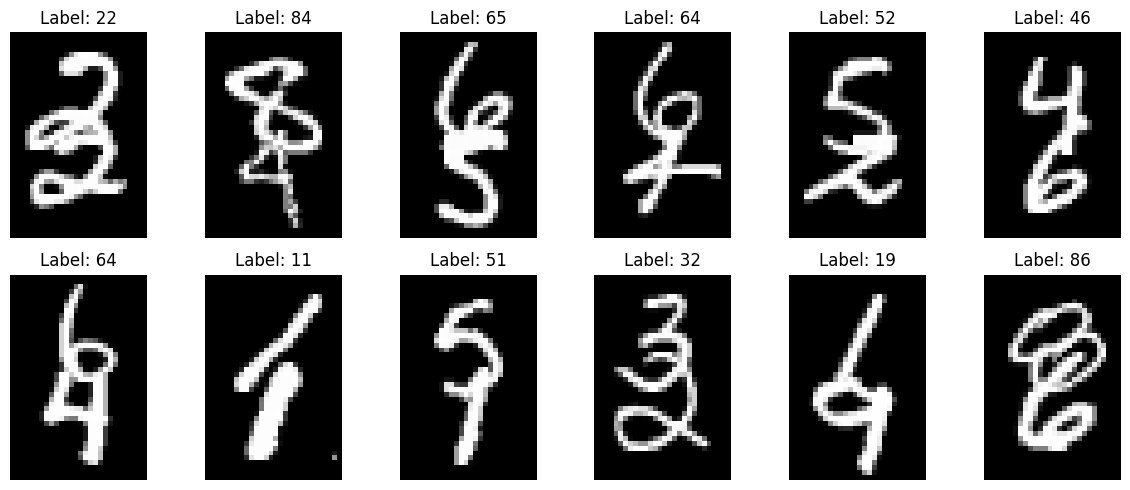

In [4]:
def show_examples(X, y, n=12):
    plt.figure(figsize=(12, 5))

    for i in range(n):
        plt.subplot(2, 6, i + 1)
        plt.imshow(X[i].squeeze(), cmap="gray")
        plt.title(f"Label: {y[i, 0]}{y[i, 1]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_examples(X_train, y_train, n=12)

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.08),
])

2026-06-30 03:05:18.240478: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
input_shape = X_train.shape[1:]

inputs = layers.Input(shape=input_shape)

x = data_augmentation(inputs)

x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.15)(x)

x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.20)(x)

x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

digit_1 = layers.Dense(10, activation="softmax", name="digit_1")(x)
digit_2 = layers.Dense(10, activation="softmax", name="digit_2")(x)

model = models.Model(inputs=inputs, outputs=[digit_1, digit_2])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "digit_1": "sparse_categorical_crossentropy",
        "digit_2": "sparse_categorical_crossentropy"
    },
    metrics={
        "digit_1": ["accuracy"],
        "digit_2": ["accuracy"]
    }
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 42, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 42, 28, 1) │          0 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 42, 28,    │        320 │ sequential[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 42, 28,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 42, 28,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 42, 28,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 21, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 21, 14,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 21, 14,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 14,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 21, 14,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 14,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 10, 7, 64) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 7, 64) │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 10, 7,     │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 7,     │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 10, 7,     │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                 

 Total params: 656,372 (2.50 MB)

 Trainable params: 654,452 (2.50 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [8]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

history = model.fit(
    X_train,
    {
        "digit_1": y_train[:, 0],
        "digit_2": y_train[:, 1]
    },
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 313ms/step - digit_1_accuracy: 0.7058 - digit_1_loss: 0.9095 - digit_2_accuracy: 0.6450 - digit_2_loss: 1.0718 - loss: 1.9813 - val_digit_1_accuracy: 0.8776 - val_digit_1_loss: 0.3972 - val_digit_2_accuracy: 0.8564 - val_digit_2_loss: 0.4195 - val_loss: 0.8166 - learning_rate: 0.0010
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 314ms/step - digit_1_accuracy: 0.9071 - digit_1_loss: 0.2848 - digit_2_accuracy: 0.8770 - digit_2_loss: 0.3681 - loss: 0.6529 - val_digit_1_accuracy: 0.9601 - val_digit_1_loss: 0.1274 - val_digit_2_accuracy: 0.9409 - val_digit_2_loss: 0.1699 - val_loss: 0.2973 - learning_rate: 0.0010
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 161s 322ms/step - digit_1_accuracy: 0.9349 - digit_1_loss: 0.2061 - digit_2_accuracy: 0.9126 - digit_2_loss: 0.2652 - loss: 0.4713 - val_digit_1_accuracy: 0.9498 - val_digit_1_loss: 0.1461 - val_digit_2_accuracy: 0.9542 - val_digit_2_loss: 0.1274 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 4/30

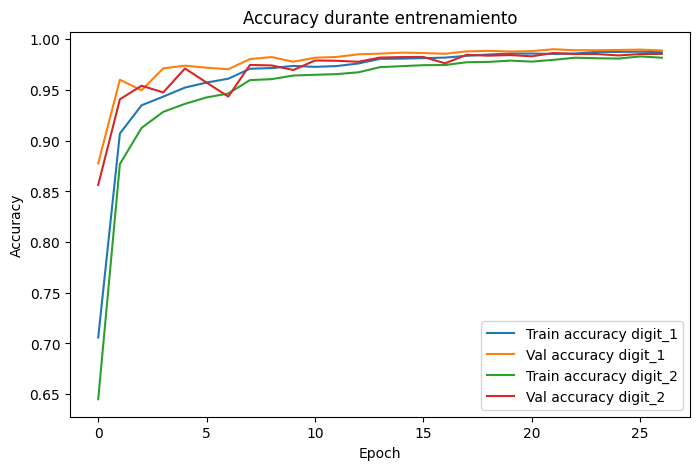

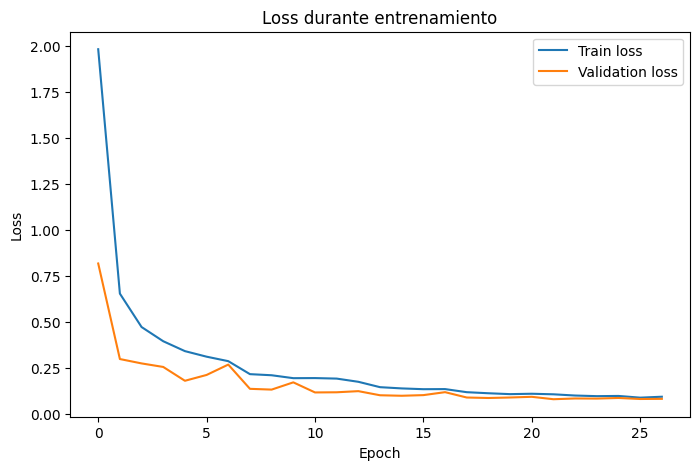

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["digit_1_accuracy"], label="Train accuracy digit_1")
plt.plot(history.history["val_digit_1_accuracy"], label="Val accuracy digit_1")
plt.plot(history.history["digit_2_accuracy"], label="Train accuracy digit_2")
plt.plot(history.history["val_digit_2_accuracy"], label="Val accuracy digit_2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy durante entrenamiento")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss durante entrenamiento")
plt.legend()
plt.show()

In [10]:
results = model.evaluate(
    X_test,
    {
        "digit_1": y_test[:, 0],
        "digit_2": y_test[:, 1]
    },
    verbose=0,
    return_dict=True
)

print("Resultados en test:")
for key, value in results.items():
    print(f"{key}: {value:.4f}")

Resultados en test:
digit_1_accuracy: 0.9880
digit_1_loss: 0.0416
digit_2_accuracy: 0.9852
digit_2_loss: 0.0442
loss: 0.0858


In [11]:
pred_digit_1, pred_digit_2 = model.predict(X_test)

pred_1 = np.argmax(pred_digit_1, axis=1)
pred_2 = np.argmax(pred_digit_2, axis=1)

predictions = np.column_stack([pred_1, pred_2])

accuracy_digit_1 = np.mean(pred_1 == y_test[:, 0])
accuracy_digit_2 = np.mean(pred_2 == y_test[:, 1])
exact_accuracy = np.mean(np.all(predictions == y_test, axis=1))

print(f"Accuracy dígito 1: {accuracy_digit_1:.4f}")
print(f"Accuracy dígito 2: {accuracy_digit_2:.4f}")
print(f"Accuracy exacta de ambos dígitos: {exact_accuracy:.4f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step
Accuracy dígito 1: 0.9880
Accuracy dígito 2: 0.9852
Accuracy exacta de ambos dígitos: 0.9732


In [12]:
print("Reporte para el primer dígito:")
print(classification_report(y_test[:, 0], pred_1))

print("Reporte para el segundo dígito:")
print(classification_report(y_test[:, 1], pred_2))

Reporte para el primer dígito:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       388
           1       0.99      0.99      0.99       471
           2       0.99      0.98      0.98       418
           3       1.00      0.99      1.00       416
           4       0.98      1.00      0.99       395
           5       0.98      0.99      0.99       349
           6       0.99      0.98      0.99       385
           7       0.97      0.98      0.97       403
           8       0.99      0.99      0.99       372
           9       0.99      0.98      0.99       403

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000

Reporte para el segundo dígito:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       387
           1       0.98      0.99      0.98       449
           2   

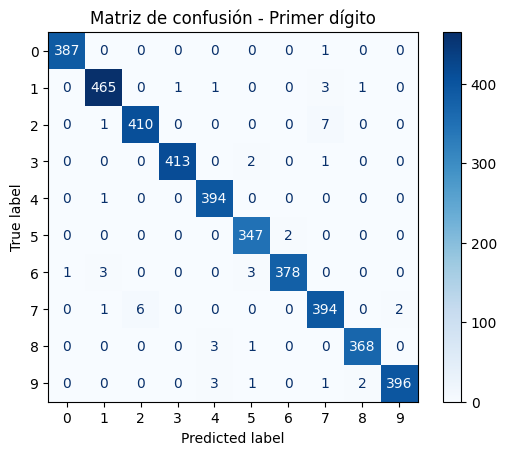

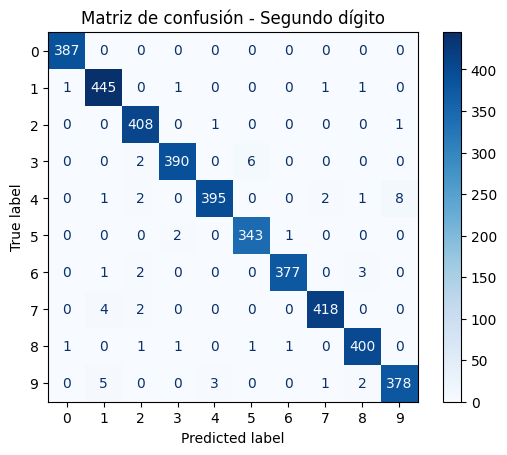

In [13]:
cm1 = confusion_matrix(y_test[:, 0], pred_1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=list(range(10)))
disp1.plot(cmap="Blues")
plt.title("Matriz de confusión - Primer dígito")
plt.show()

cm2 = confusion_matrix(y_test[:, 1], pred_2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=list(range(10)))
disp2.plot(cmap="Blues")
plt.title("Matriz de confusión - Segundo dígito")
plt.show()

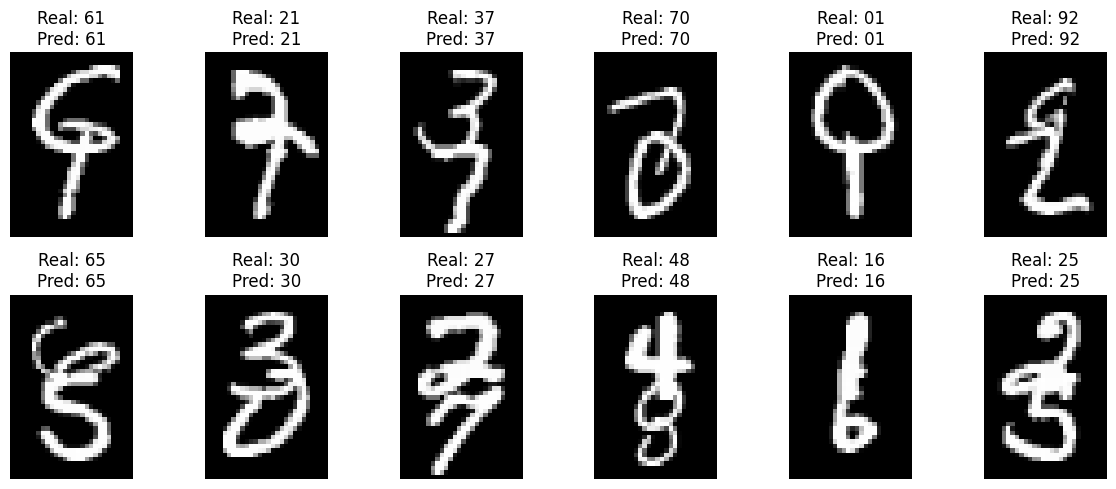

In [14]:
def show_predictions(X, y_true, y_pred, n=12):
    plt.figure(figsize=(12, 5))

    for i in range(n):
        real = f"{y_true[i, 0]}{y_true[i, 1]}"
        pred = f"{y_pred[i, 0]}{y_pred[i, 1]}"

        plt.subplot(2, 6, i + 1)
        plt.imshow(X[i].squeeze(), cmap="gray")
        plt.title(f"Real: {real}\nPred: {pred}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(X_test, y_test, predictions, n=12)